# Exploration 07: 뉴스 요약봇 만들기

## Step 1. 데이터 수집하기

In [2]:
from importlib.metadata import version
import nltk
import torch
import summa
import pandas as pd

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.9.4
2.7.1+cu118
2.3.0
1.2.0


In [3]:
# 데이터 다운로드
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv", filename="news_summary_more.csv")
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

In [4]:
data.sample(10)

,headlines,text
60823,Migrants in Libya being sold as slaves for Ã¢Â...,Migrants trying to reach Europe are being sold...
22481,"Karunanidhi had assets worth Ã¢ÂÂ¹13.42 cr, n...",Former DMK chief and five-time Tamil Nadu Chie...
94107,BJP candidate touted as slum dweller is actual...,A BJP candidate for the upcoming MCD polls in ...
71765,"Rajnath Singh, CM Yogi inaugurate Phase-I of L...",Home Minister Rajnath Singh and Uttar Pradesh ...
72465,17-year-old admin of Blue Whale Challenge arre...,"A 17-year-old girl, the alleged administrator ..."
24583,"Aliens might have lived twice on the Moon, cla...",A study has claimed that aliens might have liv...
47937,CCTVs in courtrooms not meant for recording pr...,Praising the Centre's progress in installing C...
24707,"Truckers' strike costs India Ã¢ÂÂ¹10,000 cror...",Transporter associations have pegged the natio...
92679,Pakistan passes bill on compulsory Quran teach...,Pakistan's National Assembly has passed a bill...
6268,Hockey almost dead in Pakistan: Asian Hockey F...,Speaking about the condition of hockey in Paki...


### Step 2. 데이터 전처리하기 (추상적 요약)
실습에서 사용된 전처리를 참고하여 각자 필요하다고 생각하는 전처리를 추가 사용하여 텍스트를 정규화 또는 정제해 보세요. 만약, 불용어 제거를 선택한다면 상대적으로 길이가 짧은 요약 데이터에 대해서도 불용어를 제거하는 것이 좋을지 고민해 보세요.

### Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)
일반적인 seq2seq보다는 어텐션 메커니즘을 사용한 seq2seq를 사용하는 것이 더 나은 성능을 얻을 수 있어요. 실습 내용을 참고하여 어텐션 메커니즘을 사용한 seq2seq를 설계해 보세요.

### Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)
원래의 요약문(headlines 열)과 학습을 통해 얻은 추상적 요약의 결과를 비교해 보세요.

### Step 5. Summa을 이용해서 추출적 요약해보기

## Step 2. 데이터 전처리하기 (추상적 요약)


In [5]:
# NLTK(영어 기호, 통계, 자연어 처리를 위한 라이브러리) 패키지, BeautifulSoup는 문서를 파싱 하는데 사용하는 패키지 설
!pip install -q nltk
!pip install -q beautifulsoup4

In [6]:
# 라이브러리 임포트
import nltk # 불용어 제거용
nltk.download('stopwords')

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup

import torch
from collections import Counter

import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')

[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
# 데이터 불러오기
data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98401


In [8]:
data.head()

,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


In [9]:
# headlines와 text 열만 남기기
data = data[['headlines', 'text']]
data.head()
data.sample(15)

,headlines,text
31833,"Ishan slams 4 straight sixes off Kuldeep, hits...",Mumbai Indians wicketkeeper Ishan Kishan slamm...
25821,France's MbappÃÂ© 1st teen since PelÃÂ© in 1...,French forward Kylian MbappÃÂ© has become the...
38937,B'desh men's team celebrates women's last-ball...,Bangladesh men's cricket team opener Tamim Iqb...
12288,"Sonia had Ã¢ÂÂ¹10 cr Paytm stake, why would s...",Brother-in-law of Paytm CEO Vijay Shekhar Shar...
1981,World's 1st IVF baby wishes 1st test-tube boy ...,"Louise Brown, a 40-year-old English woman know..."
52329,"Goa Minister abuses Kannada people, asks media...",Claiming that Karnataka had already started di...
17150,Multi-storied building in Kolkata on fire for ...,At least 30 fire engines have been deployed to...
87910,US airline denies gay couple family boarding p...,Claiming they were denied family boarding priv...
58805,I turn into an a**hole once I enter a public p...,Actress Jennifer Lawrence has said she turns i...
86983,Duterte offers to hire rebels as soldiers to f...,Philippine President Rodrigo Duterte has offer...


---
### (1) 데이터 정리하기

In [10]:
# 데이터 중복 샘플 유무 확인하기
print('text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280


In [11]:
# 중복 제거
data.drop_duplicates(subset=['text'], inplace=True)
print('중복 제거 후 샘플 수 :', len(data))

중복 제거 후 샘플 수 : 98360


In [12]:
# 데이터에 Null 값이 있는지 확인 
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


In [13]:
# 텍스트 정규화를 위한 사전
contractions = {"ain't": "is not", "aren't": "are not","can't": "cannot", "'cause": "because", "could've": "could have", "couldn't": "could not",
                           "didn't": "did not",  "doesn't": "does not", "don't": "do not", "hadn't": "had not", "hasn't": "has not", "haven't": "have not",
                           "he'd": "he would","he'll": "he will", "he's": "he is", "how'd": "how did", "how'd'y": "how do you", "how'll": "how will", "how's": "how is",
                           "I'd": "I would", "I'd've": "I would have", "I'll": "I will", "I'll've": "I will have","I'm": "I am", "I've": "I have", "i'd": "i would",
                           "i'd've": "i would have", "i'll": "i will",  "i'll've": "i will have","i'm": "i am", "i've": "i have", "isn't": "is not", "it'd": "it would",
                           "it'd've": "it would have", "it'll": "it will", "it'll've": "it will have","it's": "it is", "let's": "let us", "ma'am": "madam",
                           "mayn't": "may not", "might've": "might have","mightn't": "might not","mightn't've": "might not have", "must've": "must have",
                           "mustn't": "must not", "mustn't've": "must not have", "needn't": "need not", "needn't've": "need not have","o'clock": "of the clock",
                           "oughtn't": "ought not", "oughtn't've": "ought not have", "shan't": "shall not", "sha'n't": "shall not", "shan't've": "shall not have",
                           "she'd": "she would", "she'd've": "she would have", "she'll": "she will", "she'll've": "she will have", "she's": "she is",
                           "should've": "should have", "shouldn't": "should not", "shouldn't've": "should not have", "so've": "so have","so's": "so as",
                           "this's": "this is","that'd": "that would", "that'd've": "that would have", "that's": "that is", "there'd": "there would",
                           "there'd've": "there would have", "there's": "there is", "here's": "here is","they'd": "they would", "they'd've": "they would have",
                           "they'll": "they will", "they'll've": "they will have", "they're": "they are", "they've": "they have", "to've": "to have",
                           "wasn't": "was not", "we'd": "we would", "we'd've": "we would have", "we'll": "we will", "we'll've": "we will have", "we're": "we are",
                           "we've": "we have", "weren't": "were not", "what'll": "what will", "what'll've": "what will have", "what're": "what are",
                           "what's": "what is", "what've": "what have", "when's": "when is", "when've": "when have", "where'd": "where did", "where's": "where is",
                           "where've": "where have", "who'll": "who will", "who'll've": "who will have", "who's": "who is", "who've": "who have",
                           "why's": "why is", "why've": "why have", "will've": "will have", "won't": "will not", "won't've": "will not have",
                           "would've": "would have", "wouldn't": "would not", "wouldn't've": "would not have", "y'all": "you all",
                           "y'all'd": "you all would","y'all'd've": "you all would have","y'all're": "you all are","y'all've": "you all have",
                           "you'd": "you would", "you'd've": "you would have", "you'll": "you will", "you'll've": "you will have",
                           "you're": "you are", "you've": "you have"}

print("정규화 사전의 수: ", len(contractions))

정규화 사전의 수:  120


In [14]:
#  NLTK에서 제공하는 불용어 리스트 참조해 제거
print('불용어 개수 :', len(stopwords.words('english') ))
print(stopwords.words('english'))

불용어 개수 : 198
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "

In [15]:
# 데이터 전처리 함수
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "html.parser").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah

    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stopwords.words('english') if len(word) > 1)
    # 불용어 미제거 (headlines)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [16]:
temp_text = 'Everything I bought was great, infact I ordered twice and the third ordered was<br />for my mother and father.'
temp_summary = 'Great way to start (or finish) the day!!!'

print("text: ", preprocess_sentence(temp_text))
print("summary:", preprocess_sentence(temp_summary, False))  # 불용어를 제거하지 않습니다.

text:  everything bought great infact ordered twice third ordered wasfor mother father
summary: great way to start the day


In [17]:
# test 열의 모든 문장 하나씩 전처리 함수에 넣기
clean_text = []

for idx, sentence in enumerate(data['text']):
    clean_text.append(preprocess_sentence(sentence))
    if (idx + 1) % 10000 == 0:
        print(f'{idx + 1} / {len(data)} 완료')

print('전처리 완료!')

print("Text 전처리 후 결과: ", clean_text[:5])
data.to_csv('preprocessed_data.csv', index=False)

10000 / 98360 완료
20000 / 98360 완료
30000 / 98360 완료
40000 / 98360 완료
50000 / 98360 완료
60000 / 98360 완료
70000 / 98360 완료
80000 / 98360 완료
90000 / 98360 완료
전처리 완료!
Text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket

In [18]:
# headlines 데이터 전처리
clean_headlines = []

for idx, sentence in enumerate(data['headlines']):
    clean_headlines.append(preprocess_sentence(sentence, remove_stopwords=False))
    if (idx + 1) % 10000 == 0:
        print(f'{idx + 1} / {len(data)} 완료')

print('전처리 완료!')
print("headlines 전처리 후 결과: ", clean_headlines[:5])

10000 / 98360 완료
20000 / 98360 완료
30000 / 98360 완료
40000 / 98360 완료
50000 / 98360 완료
60000 / 98360 완료
70000 / 98360 완료
80000 / 98360 완료
90000 / 98360 완료
전처리 완료!
headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [19]:
data['text'] = clean_text
data['headlines'] = clean_headlines

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)

In [20]:
data.isnull().sum()


headlines    0
text         0
dtype: int64

---
### (2) 훈련데이터와 테스트데이터 나누기

텍스트의 최소 길이 : 1
텍스트의 최대 길이 : 60
텍스트의 평균 길이 : 35.09968483123221
헤드라인의 최소 길이 : 1
헤드라인의 최대 길이 : 16
헤드라인의 평균 길이 : 9.301108174054495


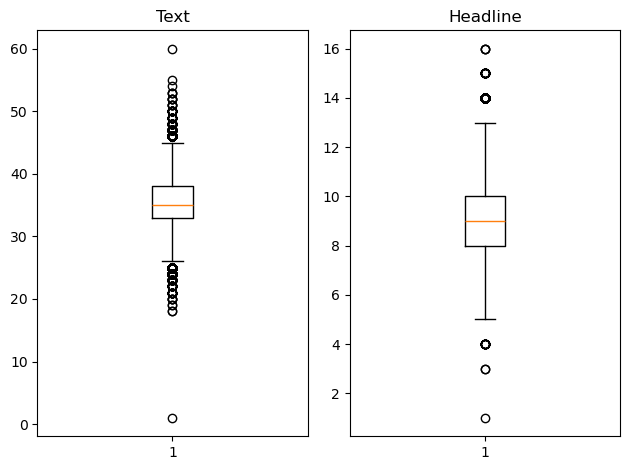

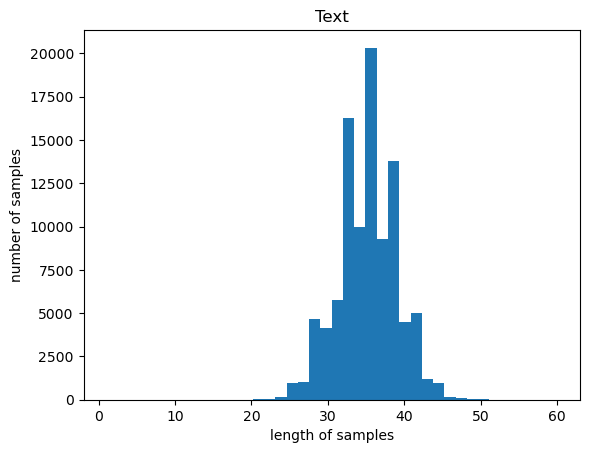

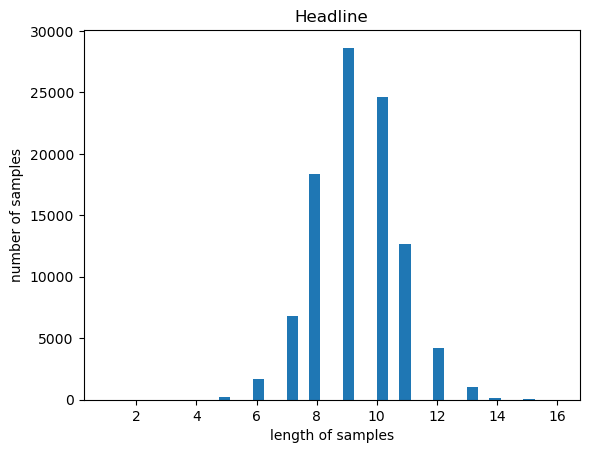

In [21]:
# 길이 분포 출력
import matplotlib.pyplot as plt

text_len = [len(s.split()) for s in data['text']]
headline_len = [len(s.split()) for s in data['headlines']]

print('텍스트의 최소 길이 : {}'.format(np.min(text_len)))
print('텍스트의 최대 길이 : {}'.format(np.max(text_len)))
print('텍스트의 평균 길이 : {}'.format(np.mean(text_len)))
print('헤드라인의 최소 길이 : {}'.format(np.min(headline_len)))
print('헤드라인의 최대 길이 : {}'.format(np.max(headline_len)))
print('헤드라인의 평균 길이 : {}'.format(np.mean(headline_len)))

plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(headline_len)
plt.title('Headline')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Headline')
plt.hist(headline_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [22]:
# max_len 잡았을 때 전체 데이터의 몇 %가 커버되는지 확인
def below_threshold_len(max_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [23]:
below_threshold_len(50, data['text'])
below_threshold_len(15, data['headlines'])

전체 샘플 중 길이가 50 이하인 샘플의 비율: 0.9998576657177715
전체 샘플 중 길이가 15 이하인 샘플의 비율: 0.9999694997966653


In [24]:
# max_len의 길이 보다 큰 샘플 제거하기
text_max_len = 50
headlines_max_len = 15

data = data[data['text'].apply(lambda x: len(x.split()) <= text_max_len)]
data = data[data['headlines'].apply(lambda x: len(x.split()) <= headlines_max_len)]
print('전체 샘플수 :', (len(data)))

전체 샘플수 : 98343


---
### (3) 시작 토큰과 종료 토큰 추가하기

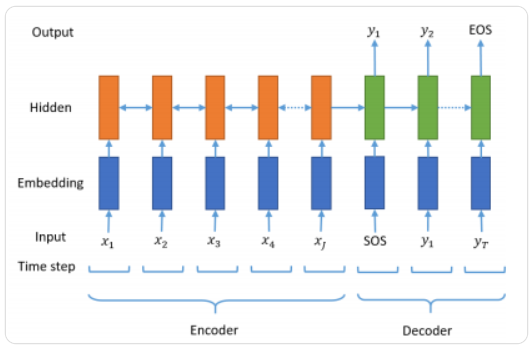
시작 토큰 SOS와 종료 토큰 EOS는 각각 start of sequence와 end of a sequence를 나타냄.

In [25]:
# 헤드라인 데이터에는 시작 토큰과 종료 토큰을 추가한다.
data['decoder_input'] = data['headlines'].apply(lambda x : 'sostoken ' + x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')
data.head()

,headlines,text,decoder_input,decoder_target
0,upgrad learner switches to career in ml al wit...,saurav kant alumnus upgrad iiit pg program mac...,sostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
1,delhi techie wins free food from swiggy for on...,kunal shah credit card bill payment platform c...,sostoken delhi techie wins free food from swig...,delhi techie wins free food from swiggy for on...
2,new zealand end rohit sharma led india match w...,new zealand defeated india wickets fourth odi ...,sostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan helps customer...,aegon life iterm insurance plan customers enjo...,sostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
4,have known hirani for yrs what if metoo claims...,speaking sexual harassment allegations rajkuma...,sostoken have known hirani for yrs what if met...,have known hirani for yrs what if metoo claims...


In [27]:
# 데이터 배열 변환
encoder_input = np.array(data['text'])
decoder_input = np.array(data['decoder_input'])
decoder_target = np.array(data['decoder_target'])
print('배열 변환 완료')

배열 변환 완료


In [28]:
# 데이터 셔플
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)

encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]
print('셔플 완료')

셔플 완료


In [29]:
# 훈련/테스트 데이터 분리
n_of_val = int(len(encoder_input) * 0.2)

encoder_input_train = encoder_input[:-n_of_val]
decoder_input_train = decoder_input[:-n_of_val]
decoder_target_train = decoder_target[:-n_of_val]

encoder_input_test = encoder_input[-n_of_val:]
decoder_input_test = decoder_input[-n_of_val:]
decoder_target_test = decoder_target[-n_of_val:]

print('훈련 데이터의 개수 :', len(encoder_input_train))
print('테스트 데이터의 개수 :', len(encoder_input_test))

훈련 데이터의 개수 : 78675
테스트 데이터의 개수 : 19668


### (3) 정수 인코딩

In [30]:
# 토크나이저 및 사전 구축 함수 정의
# 인코더용 토크나이저: 소문자 변환 + 특수문자 제거 + 공백 기준 분리
def src_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)
    return text.split()

# 디코더용 토크나이저: src_tokenizer와 동일한 방식
def tar_tokenizer(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)
    return text.split()

# 전체 단어 사전 구축: 모든 단어를 빈도 높은 순서대로 번호를 매김
# <PAD>=0 (패딩), <UNK>=1 (사전에 없는 단어) 부터 시작
def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    word_counter = Counter()
    for text in texts:
        word_counter.update(src_tokenizer(text))
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)
    return vocab

# 제한된 크기의 단어 사전 구축: 상위 vocab_size개 단어만 포함
# 나머지 희귀 단어는 <UNK>으로 처리됨
def build_limited_vocab(texts, vocab_size):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    word_counter = Counter()
    for text in texts:
        word_counter.update(src_tokenizer(text))
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)
    return vocab

# 문장 → 정수 시퀀스 변환: 각 단어를 사전의 인덱스로 바꿈
# 사전에 없는 단어는 <UNK>(1)으로 변환
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences


In [34]:
# 인코더 사전 구축 + 정수 변환
src_vocab_size = 8000
src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size)

encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

print('인코더 단어 사전 크기:', len(src_vocab))
print('인코더 시퀀스 샘플:', encoder_input_train_seq[:2])

인코더 단어 사전 크기: 8000
인코더 시퀀스 샘플: [[104, 63, 887, 31, 575, 1068, 638, 247, 3093, 7892, 74, 4778, 255, 1, 1433, 6185, 1, 3916, 61, 3572, 143, 1521, 1, 104, 375, 229, 2, 40, 763, 1, 570, 4081, 2028, 598, 1433, 2648], [5601, 354, 6633, 170, 355, 588, 51, 114, 47, 4082, 29, 1, 1, 6989, 4229, 1, 1370, 1248, 611, 794, 198, 13, 611, 1179, 648, 5601, 354, 6633, 170, 146, 14, 1, 3045, 730, 289, 523, 26, 2787]]


In [35]:
# 인코더(text) 희귀 단어 분석
threshold = 7

word_counter = Counter()
for text in encoder_input_train:
    word_counter.update(text.split())

total_cnt = len(word_counter)
total_freq = sum(word_counter.values())
rare_cnt = sum(1 for count in word_counter.values() if count < threshold)
rare_freq = sum(count for count in word_counter.values() if count < threshold)

print('단어 집합(vocabulary)의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s' % (threshold - 1, rare_cnt))
print('희귀 단어 제외 시 단어 집합의 크기: %s' % (total_cnt - rare_cnt))
print('희귀 단어의 비율: %.2f%%' % ((rare_cnt / total_cnt) * 100))
print('희귀 단어 등장 빈도 비율: %.2f%%' % ((rare_freq / total_freq) * 100))

단어 집합(vocabulary)의 크기 : 69641
등장 빈도가 6번 이하인 희귀 단어의 수: 47488
희귀 단어 제외 시 단어 집합의 크기: 22153
희귀 단어의 비율: 68.19%
희귀 단어 등장 빈도 비율: 3.49%


In [36]:
# 디코더 사전 구축 + 정수 변환
tar_vocab_size = 2000
tar_vocab = build_limited_vocab(
    list(decoder_input_train) + list(decoder_target_train), tar_vocab_size
)

decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

print('디코더 단어 사전 크기:', len(tar_vocab))
print('input 샘플:', decoder_input_train_seq[:2])
print('target 샘플:', decoder_target_train_seq[:2])

디코더 단어 사전 크기: 2000
input 샘플: [[2, 58, 318, 66, 7, 501, 4, 1, 1, 1], [2, 1, 1, 1, 4, 1, 1, 550, 1, 345]]
target 샘플: [[58, 318, 66, 7, 501, 4, 1, 1, 1, 3], [1, 1, 1, 4, 1, 1, 550, 1, 345, 3]]


In [37]:
# 빈 문장 제거
drop_train = [index for index, sentence in enumerate(decoder_input_train_seq) if len(sentence) == 1]
drop_test = [index for index, sentence in enumerate(decoder_input_test_seq) if len(sentence) == 1]
print('삭제할 훈련 데이터의 개수 :', len(drop_train))
print('삭제할 테스트 데이터의 개수 :', len(drop_test))

encoder_input_train_seq = [s for i, s in enumerate(encoder_input_train_seq) if i not in drop_train]
decoder_input_train_seq = [s for i, s in enumerate(decoder_input_train_seq) if i not in drop_train]
decoder_target_train_seq = [s for i, s in enumerate(decoder_target_train_seq) if i not in drop_train]

encoder_input_test_seq = [s for i, s in enumerate(encoder_input_test_seq) if i not in drop_test]
decoder_input_test_seq = [s for i, s in enumerate(decoder_input_test_seq) if i not in drop_test]
decoder_target_test_seq = [s for i, s in enumerate(decoder_target_test_seq) if i not in drop_test]

print('훈련 데이터의 개수 :', len(encoder_input_train_seq))
print('테스트 데이터의 개수 :', len(encoder_input_test_seq))

삭제할 훈련 데이터의 개수 : 0
삭제할 테스트 데이터의 개수 : 0
훈련 데이터의 개수 : 78675
테스트 데이터의 개수 : 19668


---
### (4) 패딩 하기

In [40]:
from torch.nn.utils.rnn import pad_sequence

# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)
decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=headlines_max_len)
decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=headlines_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=headlines_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=headlines_max_len)

print('encoder_input_train 크기:', encoder_input_train.shape)
print('decoder_input_train 크기:', decoder_input_train.shape)
print('decoder_target_train 크기:', decoder_target_train.shape)

encoder_input_train 크기: torch.Size([78675, 50])
decoder_input_train 크기: torch.Size([78675, 15])
decoder_target_train 크기: torch.Size([78675, 15])


---
### Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)

### (1) 모델 설계하기

In [41]:
# 하이퍼파라미터 설정
import torch.nn as nn
import torch.nn.functional as F

# 하이퍼파라미터 설정
embedding_dim = 128   # 단어 임베딩 벡터 차원
hidden_size = 256     # LSTM hidden state 차원
src_vocab_size = len(src_vocab)  # 인코더 단어 사전 크기
tar_vocab_size = len(tar_vocab)  # 디코더 단어 사전 크기

print('인코더 단어 사전 크기:', src_vocab_size)
print('디코더 단어 사전 크기:', tar_vocab_size)

인코더 단어 사전 크기: 8000
디코더 단어 사전 크기: 2000


In [43]:
# 인코더: 입력 문장(text)을 읽어서 각 단어의 hidden state를 출력
# embedding으로 단어를 벡터로 변환 → LSTM으로 순서대로 처리
# output: 모든 타임스텝의 hidden state (어텐션에서 사용)
# hidden, cell: 마지막 상태 (디코더의 시작점)
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)  # 단어 인덱스 → 128차원 벡터
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True  # 3층 LSTM, dropout 40%
        )

    def forward(self, x):
        embedded = self.embedding(x)                    # (batch, 50) → (batch, 50, 128)
        output, (hidden, cell) = self.lstm(embedded)    # output: (batch, 50, 256)
        return output, hidden, cell

In [44]:
# 디코더: 인코더의 마지막 hidden/cell state를 받아서 요약문을 생성
# 인코더와 구조는 같지만, 인코더의 상태를 초기값으로 받는 것이 핵심 차이
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)  # 단어 인덱스 → 128차원 벡터
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x, hidden, cell):
        embedded = self.embedding(x)                                # (batch, 15) → (batch, 15, 128)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell)) # 인코더 상태를 이어받아 시작
        return output, hidden, cell

In [45]:
# Dot-Product 어텐션: 디코더가 요약 단어를 생성할 때 원문의 어떤 부분에 집중할지 계산
# 1단계: 디코더 출력과 인코더 출력의 내적 → 유사도 점수
# 2단계: softmax로 확률 분포 변환 (합이 1)
# 3단계: 확률을 가중치로 인코더 출력의 가중합 → 컨텍스트 벡터
class Attention_dot(nn.Module):
    def __init__(self):
        super(Attention_dot, self).__init__()

    def forward(self, decoder_output, encoder_outputs):
        # (batch, 15, 256) × (batch, 256, 50) → (batch, 15, 50) : 유사도 점수
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        # 각 행의 합이 1이 되도록 정규화
        attn_weights = F.softmax(attn_weights, dim=-1)
        # (batch, 15, 50) × (batch, 50, 256) → (batch, 15, 256) : 컨텍스트 벡터
        attn_out = torch.bmm(attn_weights, encoder_outputs)
        return attn_out

In [46]:
# 전체 모델: 인코더 → 디코더 → 어텐션 → 결합 → 출력
# 디코더 출력(256)과 어텐션 컨텍스트 벡터(256)를 이어붙여(512)
# Linear로 256으로 줄이고 tanh 적용 후, 출력층에서 단어 사전 크기로 변환
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 512 → 256 (어텐션 결합)
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 256 → 단어 사전 크기 (최종 출력)

    def forward(self, encoder_input, decoder_input):
        # 1) 인코더: 원문을 읽음
        encoder_outputs, hidden, cell = self.encoder(encoder_input)

        # 2) 디코더: 인코더 상태를 받아 요약문 생성
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 3) 어텐션: 디코더 각 타임스텝이 원문의 어디를 볼지 계산
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 4) 디코더 출력 + 어텐션 결과 이어붙이기 (256 + 256 = 512)
        combined = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 5) 512 → 256으로 줄이고 tanh로 -1~1 사이 정규화
        combined = torch.tanh(self.concat(combined))

        # 6) 최종 출력: 각 위치에서 단어 사전의 모든 단어에 대한 점수
        output = self.output_layer(combined)
        return output

In [47]:
# 인코더, 디코더 객체 생성 후 전체 모델 조립
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size)
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size)
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)

print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(8000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(2000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot()
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=2000, bias=True)
)


### (2) 모델 훈련하기

In [49]:
# 설정 + 데이터 로더
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)

batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda


In [50]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in test_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(test_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        model.train()

In [51]:
%%time
# 학습 실행
train_model(model, train_loader, test_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 5.0203 | Val Loss: 4.7883
Epoch 2/50 | Train Loss: 4.6091 | Val Loss: 4.4063
Epoch 3/50 | Train Loss: 4.2604 | Val Loss: 4.0937
Epoch 4/50 | Train Loss: 3.9650 | Val Loss: 3.8469
Epoch 5/50 | Train Loss: 3.7310 | Val Loss: 3.6637
Epoch 6/50 | Train Loss: 3.5424 | Val Loss: 3.5241
Epoch 7/50 | Train Loss: 3.3888 | Val Loss: 3.4147
Epoch 8/50 | Train Loss: 3.2596 | Val Loss: 3.3277
Epoch 9/50 | Train Loss: 3.1469 | Val Loss: 3.2603
Epoch 10/50 | Train Loss: 3.0485 | Val Loss: 3.2031
Epoch 11/50 | Train Loss: 2.9609 | Val Loss: 3.1663
Epoch 12/50 | Train Loss: 2.8819 | Val Loss: 3.1348
Epoch 13/50 | Train Loss: 2.8089 | Val Loss: 3.1140
Epoch 14/50 | Train Loss: 2.7436 | Val Loss: 3.0907
Epoch 15/50 | Train Loss: 2.6834 | Val Loss: 3.0754
Epoch 16/50 | Train Loss: 2.6266 | Val Loss: 3.0678
Epoch 17/50 | Train Loss: 2.5741 | Val Loss: 3.0602
Epoch 18/50 | Train Loss: 2.5245 | Val Loss: 3.0665
Epoch 19/50 | Train Loss: 2.4788 | Val Loss: 3.0605
Early stopping trigge

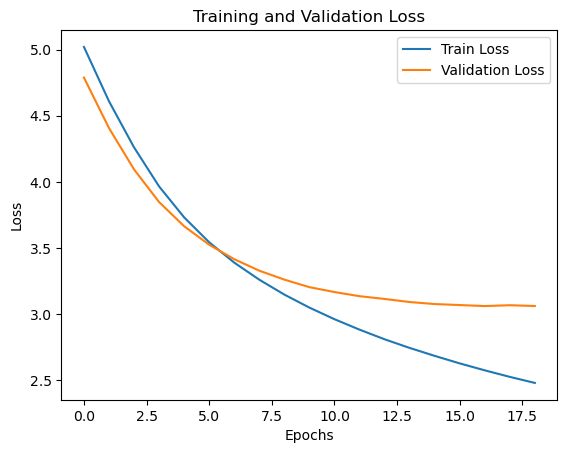

In [52]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

### (3) 인퍼런스 모델 구현하기

In [53]:
# 단어 사전 역변환 준비
# 정수 → 단어 변환을 위한 역사전 생성
# 학습할 때는 단어→정수가 필요했지만, 추론할 때는 정수→단어가 필요
src_index_to_word = {idx: word for word, idx in src_vocab.items()}
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()}

print('역사전 생성 완료')
print('인코더 역사전 크기:', len(src_index_to_word))
print('디코더 역사전 크기:', len(tar_index_to_word))

역사전 생성 완료
인코더 역사전 크기: 8000
디코더 역사전 크기: 2000


In [55]:
# 추론 함수 정의
def decode_sequence(input_seq, model, tar_vocab, tar_index_to_word, summary_max_len, device):
    """
    학습된 모델로 새로운 문장을 요약하는 함수
    학습 때와 달리 정답이 없으므로, <SOS>부터 시작해서 한 단어씩 직접 생성
    
    과정:
    1) 인코더에 원문을 넣어 encoder_outputs, hidden, cell을 얻음
    2) <SOS> 토큰으로 디코더 시작
    3) 매 스텝마다: 디코더 실행 → 어텐션 적용 → 가장 확률 높은 단어 선택
    4) 선택한 단어를 다음 입력으로 사용
    5) <EOS>가 나오거나 최대 길이에 도달하면 종료
    """
    model.eval()
    
    # 입력을 텐서로 변환 (배치 크기 1)
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device).unsqueeze(0)
    
    with torch.no_grad():
        # 1) 인코더 실행: 원문을 읽어서 상태 저장
        encoder_outputs, hidden, cell = model.encoder(input_seq)
        
        # 2) <SOS> 토큰으로 시작
        target_seq = torch.tensor([[tar_vocab['sostoken']]], dtype=torch.long, device=device)
        
        decoded_sentence = ''
        
        for _ in range(summary_max_len):
            # 3) 디코더 실행: 현재 토큰 하나를 넣어 출력 얻기
            decoder_output, hidden, cell = model.decoder(target_seq, hidden, cell)
            
            # 4) 어텐션 적용: 디코더 출력이 인코더의 어디를 볼지 계산
            attn_out = model.attention(decoder_output, encoder_outputs)
            
            # 5) 디코더 출력 + 어텐션 결과 결합
            combined = torch.cat((decoder_output, attn_out), dim=-1)
            combined = torch.tanh(model.concat(combined))
            
            # 6) 출력층: 단어 사전의 모든 단어에 대한 점수 계산
            output = model.output_layer(combined)
            
            # 7) 가장 점수가 높은 단어 선택
            predicted_id = output.argmax(dim=-1).item()
            predicted_word = tar_index_to_word.get(predicted_id, '<UNK>')
            
            # 8) <EOS>가 나오면 종료
            if predicted_word == 'eostoken':
                break
            
            decoded_sentence += ' ' + predicted_word
            
            # 9) 예측한 단어를 다음 디코더 입력으로 사용
            target_seq = torch.tensor([[predicted_id]], dtype=torch.long, device=device)
    
    return decoded_sentence.strip()

### Step 5. 실제 결과와 요약문 비교하기 (추상적 요약)

In [62]:
for i in range(50, 100):
    print("원문 :", seq_to_text(encoder_input_test[i], src_index_to_word))
    print("실제 요약 :", seq_to_text(decoder_target_test[i], tar_index_to_word))
    
    input_seq = encoder_input_test[i].tolist()
    print("예측 요약 :", decode_sequence(input_seq, model, tar_vocab, tar_index_to_word, headlines_max_len, device))
    print()

원문 : us ban citizens travelling north korea came force friday months death american student <UNK> country months <UNK> could face years imprisonment north korean tourism officials said us government says americans cannot come country care bit
실제 요약 : us ban on travel to north korea takes <UNK> today
예측 요약 : us bans <UNK> <UNK> after <UNK> <UNK>

원문 : congress friday submitted breach privilege motion union minister parliamentary affairs ananth kumar misleading lower house <UNK> naming leaders sonia gandhi rahul gandhi notice also accused government interested running house comes opposition trust motion discussed due <UNK>
실제 요약 : cong gives breach of <UNK> notice against union minister
예측 요약 : congress <UNK> <UNK> <UNK> to <UNK> gandhi

원문 : actor kamal haasan said rajinikanth suitable ally saffron party due religious <UNK> <UNK> another path set path use comparison <UNK> added haasan met delhi chief minister arvind kejriwal last week
실제 요약 : rajinikanth more <UNK> <UNK> for <UNK> party

---
# 추상적 요약(Abstractive Summarization) 결과 분석

## 학습 결과

- Train Loss와 Validation Loss 모두 꾸준히 감소하여 모델이 성공적으로 학습됨
- Epoch 5~6 이후 Train Loss는 계속 감소하지만 Validation Loss는 약 3.0에서 수렴 → 과적합 시작
- 최종 Train Loss: 약 2.5 / Validation Loss: 약 3.0

## 추론 결과 (주요 샘플)

| 실제 요약 | 예측 요약 | 평가 |
|---|---|---|
| us ban on travel to north korea takes... | us bans \<UNK\> after \<UNK\> | 핵심 키워드(us, bans) 포착 |
| new song from arjun \<UNK\> released | new song from arjun \<UNK\> starrer \<UNK\> released | 거의 동일한 구조로 예측 |
| indigo apologises after woman \<UNK\> off... | indigo apologises after \<UNK\> falls into airport | 핵심 의미 정확히 포착 |
| federer becomes oldest wimbledon... | federer oldest wimbledon to win... | 핵심 키워드 포착 |
| govt \<UNK\> lakh crore of tax \<UNK\> in years | govt \<UNK\> lakh crore for money \<UNK\> in yrs | 핵심 수치/키워드 일치 |
| miss \<UNK\> mocks \<UNK\> for english... | miss miss miss miss miss... | 단어 반복 루프 발생 (실패) |

## 한계점

- 디코더 단어 사전 크기(2,000)가 작아 \<UNK\>가 다수 발생
- 일부 샘플에서 동일 단어 반복 현상 발생
- 핵심 키워드는 잘 포착하지만 문법적 완성도는 부족한 경우 존재

---

### Step 6. Summa을 이용해서 추출적 요약해보기

In [63]:
!pip install summa

In [69]:
from summa.summarizer import summarize

# 전처리 전 원본 데이터 (Summa는 원문 그대로 넣어야 함)
original_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

# 테스트할 샘플 몇 개 선택해서 비교
for i in range(5):
    text = original_data['text'].iloc[i]
    headline = original_data['headlines'].iloc[i]
    
    # 추출적 요약 (Summa)
    extractive = summarize(text, words=10)
    if extractive == '':
        extractive = '(텍스트가 너무 짧아 추출 불가)'
    
    print('=' * 60)
    print('원문:', text[:100], '...')
    print('실제 요약:', headline)
    print('추출적 요약 (Summa):', extractive)
    print()

원문: Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelli ...
실제 요약: upGrad learner switches to career in ML & Al with 90% salary hike
추출적 요약 (Summa): upGrad's Online Power Learning has powered 3 lakh+ careers.

원문: Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swig ...
실제 요약: Delhi techie wins free food from Swiggy for one year on CRED
추출적 요약 (Summa): (텍스트가 너무 짧아 추출 불가)

원문: New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first ...
실제 요약: New Zealand end Rohit Sharma-led India's 12-match winning streak
추출적 요약 (Summa): The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history.

원문: With Aegon Life iTerm Insurance plan, customers can enjoy tax benefits on your premiums paid and sav ...
실제 요약: Aegon life iTerm insurance plan helps customers save tax
추출적 요약 (Summa): (텍스트가 너무 짧아 추출 불가)

원문: Speaking about t

---
위처럼 words 수를 Abstractive 요약과 비슷하게 10단어 정도로 설정하니까 텍스트가 너무 짧아서 추출 불가함.

In [70]:
from summa.summarizer import summarize

# 전처리 전 원본 데이터 (Summa는 원문 그대로 넣어야 함)
original_data = pd.read_csv('news_summary_more.csv', encoding='iso-8859-1')

# 테스트할 샘플 몇 개 선택해서 비교
for i in range(5):
    text = original_data['text'].iloc[i]
    headline = original_data['headlines'].iloc[i]
    
    # 추출적 요약 (Summa)
    extractive = summarize(text, words=15)
    if extractive == '':
        extractive = '(텍스트가 너무 짧아 추출 불가)'
    
    print('=' * 60)
    print('원문:', text[:100], '...')
    print('실제 요약:', headline)
    print('추출적 요약 (Summa):', extractive)
    print()

원문: Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelli ...
실제 요약: upGrad learner switches to career in ML & Al with 90% salary hike
추출적 요약 (Summa): upGrad's Online Power Learning has powered 3 lakh+ careers.

원문: Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swig ...
실제 요약: Delhi techie wins free food from Swiggy for one year on CRED
추출적 요약 (Summa): Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.Fit and more.

원문: New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first ...
실제 요약: New Zealand end Rohit Sharma-led India's 12-match winning streak
추출적 요약 (Summa): The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history.

원문: With Aegon Life iTerm Insurance plan, customers can enjoy tax benefits on your premiums paid and

In [71]:
for i in range(5):
    text = original_data['text'].iloc[i]
    headline = original_data['headlines'].iloc[i]
    
    # 추출적 요약 (Summa)
    extractive = summarize(text, words=15)
    if extractive == '':
        extractive = '(텍스트가 너무 짧아 추출 불가)'
    
    # 추상적 요약 (우리 모델)
    clean = preprocess_sentence(text)
    seq = [src_vocab.get(word, src_vocab["<UNK>"]) for word in clean.split()]
    seq = seq[:text_max_len] + [0] * max(0, text_max_len - len(seq))
    abstractive = decode_sequence(seq, model, tar_vocab, tar_index_to_word, headlines_max_len, device)
    
    print('=' * 60)
    print('원문:', text[:100], '...')
    print('실제 요약:', headline)
    print('추출적 요약:', extractive)
    print('추상적 요약:', abstractive)
    print()

원문: Saurav Kant, an alumnus of upGrad and IIIT-B's PG Program in Machine learning and Artificial Intelli ...
실제 요약: upGrad learner switches to career in ML & Al with 90% salary hike
추출적 요약: upGrad's Online Power Learning has powered 3 lakh+ careers.
추상적 요약: <UNK> <UNK> <UNK> <UNK> to <UNK> jobs

원문: Kunal Shah's credit card bill payment platform, CRED, gave users a chance to win free food from Swig ...
실제 요약: Delhi techie wins free food from Swiggy for one year on CRED
추출적 요약: Users get one CRED coin per rupee of bill paid, which can be used to avail rewards from brands like Ixigo, BookMyShow, UberEats, Cult.Fit and more.
추상적 요약: <UNK> <UNK> to get free <UNK> to <UNK> <UNK>

원문: New Zealand defeated India by 8 wickets in the fourth ODI at Hamilton on Thursday to win their first ...
실제 요약: New Zealand end Rohit Sharma-led India's 12-match winning streak
추출적 요약: The match witnessed India getting all out for 92, their seventh lowest total in ODI cricket history.
추상적 요약: nz win their first

---
## Extractive vs Abstractive 요약 결과 비교

### 요약 결과

| 샘플 | 실제 요약 | 추출적 요약 (Summa) | 추상적 요약 (Seq2Seq + Attention) |
|---|---|---|---|
| 1 | upGrad learner switches to career in ML & Al with 90% salary hike | upGrad's Online Power Learning has powered 3 lakh+ careers. | \<UNK\> \<UNK\> \<UNK\> to \<UNK\> jobs |
| 2 | Delhi techie wins free food from Swiggy for one year on CRED | Users get one CRED coin per rupee of bill paid... | \<UNK\> \<UNK\> to get free \<UNK\> to \<UNK\> |
| 3 | New Zealand end India's 12-match winning streak | India getting all out for 92, their seventh lowest total in ODI history. | nz win their first odi odi \<UNK\> to win odi series |
| 4 | Aegon life iTerm insurance plan helps customers save tax | customers have options to insure against Critical Illnesses... | \<UNK\> life insurance insurance insurance \<UNK\> |
| 5 | Have known Hirani for yrs, what if MeToo claims are not true: Sonam | (텍스트가 너무 짧아 추출 불가) | \<UNK\> \<UNK\> on sexual harassment \<UNK\> sonam |

### 문법완성도 비교

| 항목 | 추출적 요약 (Summa) | 추상적 요약 (Seq2Seq + Attention) |
|---|---|---|
| 문장 구조 | 원문 문장을 그대로 추출하므로 문법적으로 완전함 | 단어를 새로 조합하므로 문법 오류 발생 |
| 가독성 | 자연스럽고 읽기 쉬움 | \<UNK\> 토큰이 많아 가독성 떨어짐 |
| 문장 길이 | 문장 단위 추출이라 여전히 긴 경우 존재 | 짧고 간결한 헤드라인 형태 |
| 종합 | **우수** | 부족 |

### 핵심단어 포함 비교

| 항목 | 추출적 요약 (Summa) | 추상적 요약 (Seq2Seq + Attention) |
|---|---|---|
| 핵심 키워드 | 원문 단어가 그대로 유지됨 | 사전 내 키워드는 잘 포착 (nz, win, odi, sonam 등) |
| 고유명사 | 정확히 보존됨 | 사전 크기 제한으로 \<UNK\> 처리되는 경우 많음 |
| 핵심 의미 | 세부 정보 포함되나 핵심 문장이 아닌 문장이 선택되기도 함 | 핵심 주제는 파악하나 세부 정보 손실 |
| 종합 | **우수** (단, 핵심 문장 선택 정확도 불안정) | 주요 키워드 포착 가능하나 정보 손실 존재 |

### 결론
- **추출적 요약(Summa)**: 문법완성도가 높고 고유명사가 보존되지만, 문장 단위 추출이라 길이 조절이 어렵고 핵심 문장이 아닌 문장이 선택되는 경우 존재
- **추상적 요약(Seq2Seq + Attention)**: 짧고 간결한 요약을 생성하고 핵심 키워드를 포착하지만, 단어 사전 크기(2,000) 제한으로 \<UNK\> 다수 발생. 사전 크기 확대 또는 서브워드 토크나이저(BPE) 적용 시 성능 개선 기대

### 회고
- 데이터 분석(중복, 결측값, 길이 분포)부터 전처리, 모델 설계, 학습, 추론까지 전체 파이프라인을 체계적으로 진행면서 내용이 더 명확히 이해되었다.
- 디코더 단어 사전 크기(2,000)가 작아 \<UNK\>가 많이 발생하여 요약 품질이 저하되는 부분을 더 늘려서 실험 해봐야겠다.